In [1]:
import numpy as np
import pandas as pd
from collections import Counter


In [2]:
def entropy(y):
    counts = np.bincount(y)
    probs = counts / len(y)
    return -np.sum([p*np.log2(p) for p in probs if p > 0])


In [3]:
def information_gain(X_column, y):
    parent_entropy = entropy(y)
    
    values = np.unique(X_column)
    weighted_entropy = 0
    
    for v in values:
        subset_y = y[X_column == v]
        weight = len(subset_y) / len(y)
        weighted_entropy += weight * entropy(subset_y)
    
    return parent_entropy - weighted_entropy


In [4]:
class DecisionTreeID3:
    
    def fit(self, X, y, feature_names=None):
        self.feature_names = feature_names
        self.tree = self._build_tree(X, y)
    
    
    def _build_tree(self, X, y):
        
        # Step iii: if all samples same class
        if len(np.unique(y)) == 1:
            return y[0]
        
        # Step iv: if no features remain
        if X.shape[1] == 0:
            return Counter(y).most_common(1)[0][0]
        
        # Step v: compute information gain for each feature
        gains = [information_gain(X[:,i], y) for i in range(X.shape[1])]
        
        # Step vi: choose feature with highest gain
        best_feature = np.argmax(gains)
        
        tree = {best_feature:{}}
        
        # Step vii: split dataset
        values = np.unique(X[:,best_feature])
        
        for v in values:
            subset_X = X[X[:,best_feature] == v]
            subset_y = y[X[:,best_feature] == v]
            
            # remove used feature
            subset_X = np.delete(subset_X, best_feature, axis=1)
            
            # Step viii: recursive call
            subtree = self._build_tree(subset_X, subset_y)
            tree[best_feature][v] = subtree
        
        return tree
    
    
    def predict_one(self, x, tree=None):
        if tree is None:
            tree = self.tree
        
        # leaf node
        if not isinstance(tree, dict):
            return tree
        
        feature = list(tree.keys())[0]
        value = x[feature]
        
        if value in tree[feature]:
            subtree = tree[feature][value]
            x = np.delete(x, feature)
            return self.predict_one(x, subtree)
        else:
            return None
    
    
    def predict(self, X):
        return np.array([self.predict_one(x.copy()) for x in X])


In [5]:
# Outlook, Temperature, Humidity, Wind
X = np.array([
    [0,0,0,0],
    [0,0,0,1],
    [1,0,0,0],
    [2,1,0,0],
    [2,2,1,0],
    [2,2,1,1],
    [1,2,1,1],
    [0,1,0,0],
    [0,2,1,0],
    [2,1,1,0],
    [0,1,1,1],
    [1,1,0,1],
    [1,0,1,0],
    [2,1,0,1]
])

# Play Tennis labels
y = np.array([0,0,1,1,1,0,1,0,1,1,1,1,1,0])


In [6]:
model = DecisionTreeID3()
model.fit(X, y)

print("Constructed Tree:\n", model.tree)


Constructed Tree:
 {np.int64(0): {np.int64(0): {np.int64(1): {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}}, np.int64(1): np.int64(1), np.int64(2): {np.int64(2): {np.int64(0): np.int64(1), np.int64(1): np.int64(0)}}}}


In [7]:
preds = model.predict(X)
print("Predictions:", preds)


Predictions: [0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [13]:
import matplotlib.pyplot as plt

def plot_tree(tree, x=0, y=0, dx=1.5, dy=1, parent=None, label=""):
    
    # leaf node
    if not isinstance(tree, dict):
        plt.text(x, y, f"Class {tree}",
                 ha='center', va='center',
                 bbox=dict(boxstyle="round", fc="lightgreen"))
        
        if parent:
            plt.plot([parent[0], x], [parent[1], y], 'k-')
            plt.text((parent[0]+x)/2, (parent[1]+y)/2, label)
        return
    
    feature = list(tree.keys())[0]
    
    plt.text(x, y, f"Feature {feature}",
             ha='center', va='center',
             bbox=dict(boxstyle="round", fc="lightblue"))
    
    if parent:
        plt.plot([parent[0], x], [parent[1], y], 'k-')
        plt.text((parent[0]+x)/2, (parent[1]+y)/2, label)
    
    children = list(tree[feature].items())
    n = len(children)
    start_x = x - dx*(n-1)/2
    
    for i, (value, subtree) in enumerate(children):
        child_x = start_x + i*dx
        child_y = y - dy 
        
        plot_tree(subtree, child_x, child_y, dx/1.5, dy,
                  (x,y), str(value))


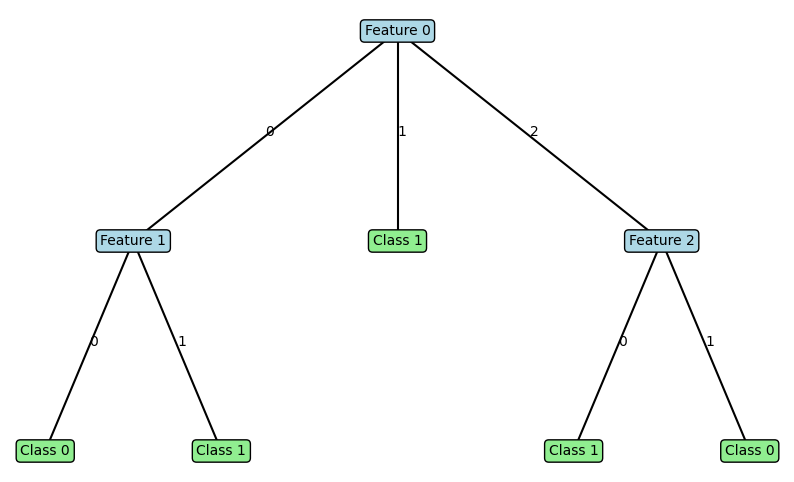

In [14]:
plt.figure(figsize=(10,6))
plot_tree(model.tree)
plt.axis('off')
plt.show()
